# Four interrogation signals: environmental recovery comparison

This notebook shows four complex interrogation signals and compares the
perturbation recovered from each one.

The comparison figure intentionally uses two different views:

1. **Whale-call-like and seismic-like rows:** repeated fast OFDR measurements
   are represented as environmental time traces at one fixed cable position.
2. **Temperature-like row:** one observation day is fixed and the disturbance
   is plotted against position along the cable.

The temperature row therefore displays

$$
g(z,T_0)
$$

with \(T_0=1\) day. It does **not** represent one optical signal taking one
day to return. Every individual interrogation still travels through the fiber
and returns on the millisecond scale.

In every panel, the black curve is the prescribed true perturbation and the
colored curve is the recovered perturbation. The recovery is

$$
\widehat g(z,T)=
\arg\left(
m_{\mathrm{pert},x}\overline{m_{\mathrm{ideal},x}}
+
m_{\mathrm{pert},y}\overline{m_{\mathrm{ideal},y}}
\right).
$$


In [1]:
# NumPy is used for arrays and complex-valued calculations.
import numpy as np

# Matplotlib creates the interrogation-signal and recovery figures.
import matplotlib.pyplot as plt

# FFT convolution evaluates the return signal and matched filter efficiently.
from scipy.signal import fftconvolve

# Use a consistent default figure size and compact numerical printing.
plt.rcParams["figure.figsize"] = (10, 5)
np.set_printoptions(precision=5, suppress=True)


## 1. Fiber parameters and the four interrogation signals

This section defines the cable travel-time grid and constructs the four signals used to interrogate the simulated fiber. Each signal is sampled over the same finite pulse interval and normalized to have unit energy so that the recovery comparison is not determined only by one signal having a larger overall scale.


In [2]:
# ----------------------------------------------------------------
# Fiber constants and sampling grid
# ----------------------------------------------------------------

# The cable is 1000 km long. Light travels more slowly in glass than in
# vacuum, so the vacuum speed of light is divided by the refractive index.
fiber_length_km = 1000.0
refractive_index = 1.468
speed_of_light_m_per_s = 299_792_458.0
speed_in_fiber_m_per_s = speed_of_light_m_per_s/refractive_index

# f_0 is the starting frequency in the baseband model. gamma is the rate
# at which the chirp frequency increases, and alpha controls attenuation
# with distance along the fiber.
f_0 = 0.0
gamma = 5e6
alpha = 3.5e-6

# Convert the cable length to meters and calculate the one-way travel time.
fiber_length_m = 1000.0*fiber_length_km
T_oneway = fiber_length_m/speed_in_fiber_m_per_s

# tau is the one-way delay associated with each of the 1001 cable positions.
# Multiplying tau by the speed in the fiber converts delay back to position.
# fast_time is twice tau because the interrogation signal travels to a
# scatterer and then returns to the source.
num_ranges = 1001
tau = np.linspace(0.0, T_oneway, num_ranges)
z_km = tau*speed_in_fiber_m_per_s/1000.0
fast_time = 2.0*tau
dt_tau = tau[1]-tau[0]
dt_fast = fast_time[1]-fast_time[0]

# Every interrogation signal is transmitted only during this pulse interval.
# Here the pulse lasts for 10 percent of the one-way cable travel time.
t_pulse_end = 0.1*T_oneway


def pulse_window(values, t, pulse_end):
    # Set the waveform equal to zero before the pulse starts and after it ends.
    return np.where((t >= 0.0) & (t <= pulse_end), values, 0.0)


def linear_chirp(t, pulse_end):
    # Create a finite pulse whose instantaneous frequency increases linearly.
    # Integrating f(t)=f_0+gamma*t gives the phase in cycles.
    phase_cycles = f_0*t+0.5*gamma*t**2

    # Multiplication by 2*pi converts cycles to radians. The factor 1j makes
    # this the complex analytic signal exp(i*phase).
    return pulse_window(np.exp(2j*np.pi*phase_cycles), t, pulse_end)


def pure_tone(t, pulse_end):
    # Create a finite pulse with one constant frequency.
    # Use the chirp's frequency at the midpoint of the pulse. This gives a
    # representative single frequency over the same pulse duration.
    frequency = f_0+0.5*gamma*pulse_end
    return pulse_window(np.exp(2j*np.pi*frequency*t), t, pulse_end)


def complex_fourier_signal(t, pulse_end, coefficients):
    # Add several Fourier modes, each with its own complex coefficient.
    # Start with zero and add the modes n=1,...,N. Mode n completes n cycles
    # over the pulse, so its frequency is n/pulse_end.
    values = np.zeros_like(t, dtype=complex)
    for mode, coefficient in enumerate(coefficients, start=1):
        # The coefficient sets the amplitude and initial phase of this mode.
        values += coefficient*np.exp(
            2j*np.pi*mode*t/pulse_end
        )

    # The Fourier sum is also restricted to the common pulse interval.
    return pulse_window(values, t, pulse_end)


# These four fixed coefficients make a short Fourier signal whose individual
# mode weights can be read directly from the list.
hand_coefficients = np.array([
    1.00+0.00j,
    0.50+0.40j,
    0.25-0.20j,
    0.10+0.10j,
])

# These twenty coefficients are drawn once from a seeded random generator.
# The seed makes the same signal appear every time the notebook is run.
# Each complex coefficient has a random real and imaginary part, so both its
# amplitude and initial phase are generally different from the other modes.
rng_signal = np.random.default_rng(5)
random_coefficients = (
    rng_signal.normal(size=20)
    + 1j*rng_signal.normal(size=20)
)/np.sqrt(2.0)

# Store the four signal-generating functions under the names used in the plots.
# The lambda functions insert the appropriate coefficient array while keeping
# the same two-input format as the chirp and pure-tone functions.
signal_functions = {
    "Linear chirp": linear_chirp,
    "Pure tone": pure_tone,
    "Hand-chosen complex Fourier": (
        lambda t, T: complex_fourier_signal(
            t,
            T,
            hand_coefficients,
        )
    ),
    "Random complex Fourier": (
        lambda t, T: complex_fourier_signal(
            t,
            T,
            random_coefficients,
        )
    ),
}


def sample_normalized_signal(signal_function):
    # Sample one pulse and scale its discrete energy to one.
    # Use the same fast-time spacing as the simulated return signal so the
    # later convolutions use compatible samples.
    number_samples = int(np.floor(t_pulse_end/dt_fast))+1
    pulse_time = np.arange(number_samples)*dt_fast
    samples = signal_function(pulse_time, t_pulse_end)

    # The sum approximates the energy integral int |c(t)|^2 dt. Dividing by
    # its square root gives every interrogation signal unit energy.
    energy = np.sum(np.abs(samples)**2)*dt_fast
    return pulse_time, samples/np.sqrt(energy)


# Generate and normalize all four pulses once so the same samples are reused
# for the signal plots and every environmental recovery calculation.
signal_samples = {
    name: sample_normalized_signal(function)
    for name, function in signal_functions.items()
}

print("Four signals created:", list(signal_samples))


Four signals created: ['Linear chirp', 'Pure tone', 'Hand-chosen complex Fourier', 'Random complex Fourier']


## 2. The four transmitted signals

These are the interrogation waveforms supplied to the simulated fiber. The linear chirp and pure tone are complex exponentials. The two Fourier signals are complex-valued sums

$$
c(t)=\sum_{n=1}^{N}a_ne^{2\pi i n t/T}.
$$

For each Fourier mode, (n/T) is a fixed frequency and the complex coefficient (a_n) determines its amplitude and initial phase. The real and imaginary parts are plotted separately so that both parts of each complex waveform can be seen. The (2\times2), 16:9 layout is designed to fit a rectangular presentation slide without stretching.


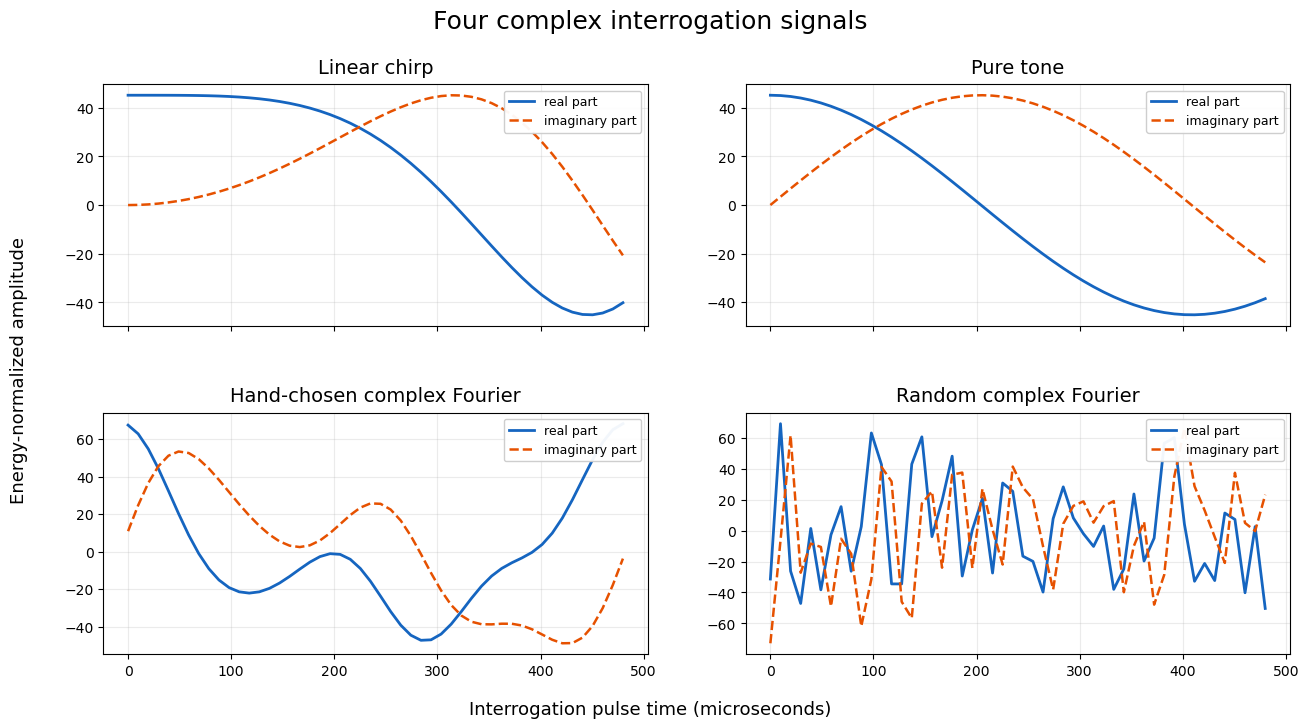

In [3]:
# Make one panel for each interrogation signal. Sharing the horizontal axis
# makes it easier to compare the signals over the same pulse duration.
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13.333, 7.5),
    sharex=True,
)
axes = axes.ravel()

# Each dictionary entry contains the time samples and normalized complex pulse.
for ax, (name, (pulse_time, samples)) in zip(
    axes,
    signal_samples.items(),
):
    # Plot the two components separately because the interrogation signals are
    # complex-valued and cannot be represented by one real curve alone.
    ax.plot(
        pulse_time*1e6,
        samples.real,
        color="#1565C0",
        linewidth=2.0,
        label="real part",
    )
    ax.plot(
        pulse_time*1e6,
        samples.imag,
        color="#E65100",
        linewidth=1.8,
        linestyle="--",
        label="imaginary part",
    )
    ax.set_title(name, fontsize=14, pad=8)
    ax.tick_params(labelsize=10)
    ax.grid(alpha=0.25)
    ax.legend(
        loc="upper right",
        fontsize=9,
        framealpha=0.95,
    )

# Label the time axis in microseconds because the optical pulse is much faster
# than the environmental time scales used later in the notebook.
fig.suptitle(
    "Four complex interrogation signals",
    fontsize=18,
    y=0.98,
)
fig.supxlabel(
    "Interrogation pulse time (microseconds)",
    fontsize=13,
    y=0.035,
)
fig.supylabel(
    "Energy-normalized amplitude",
    fontsize=13,
    x=0.02,
)

# Set the margins explicitly so the title, shared labels, and panels do not
# overlap when the figure is placed on a 16:9 slide.
fig.subplots_adjust(
    left=0.09,
    right=0.98,
    bottom=0.12,
    top=0.88,
    hspace=0.36,
    wspace=0.18,
)
plt.show()


## 3. Three source-informed synthetic perturbation families

All three disturbances in this notebook are simulated. They are **not observations**, and the numerical parameter values are illustrative choices.

The construction separates three ideas:

1. a simulated environmental field;
2. the effect that field has on the cable;
3. the optical phase perturbation (g(z,T)) used in the OFDR experiment.

The seismic construction is guided by the fact that distributed acoustic sensing responds to inline cable strain over a spatial interval:

- A. Sladen et al., *Distributed sensing of earthquakes and ocean-solid Earth interactions on seafloor telecom cables* (2019): https://doi.org/10.1038/s41467-019-13793-z
- A. Fichtner et al., *Theory of phase transmission fibre-optic deformation sensing* (2022): https://doi.org/10.1093/gji/ggac237

The temperature construction is guided by the fact that temperature changes can alter Rayleigh backscatter measured by swept-wavelength interferometry:

- D. K. Gifford et al., *Distributed fiber-optic temperature sensing using Rayleigh backscatter* (2005): https://ieeexplore.ieee.org/document/1576361

Each field is normalized to a peak optical phase magnitude of (0.8) radians. This gives the three families the same phase scale, so the notebook compares recovery shape and error rather than absolute earthquake strain or degrees Celsius.


In [4]:
# Use the same peak phase magnitude for all three disturbances. This removes
# absolute scale as a reason one disturbance might appear easier to recover.
target_peak_phase = 0.8


def normalize_field(field):
    """Scale a synthetic field to the shared peak optical phase."""
    # The largest absolute value becomes target_peak_phase, while the shape and
    # relative signs of the field stay unchanged.
    maximum = np.max(np.abs(field))
    if maximum == 0.0:
        raise ValueError("Cannot normalize a field whose maximum is zero.")
    return target_peak_phase*field/maximum


def call_packet(u, duration=1.0, f_start=18.0, f_end=22.0):
    """Finite-duration chirped packet used only for the whale-call-like test."""
    # Only values between 0 and duration belong to the call. The sine-squared
    # window starts and ends at zero, which avoids an abrupt edge.
    inside = (u >= 0.0) & (u <= duration)
    window = np.where(inside, np.sin(np.pi*u/duration)**2, 0.0)

    # The frequency changes linearly from f_start to f_end. Integrating that
    # frequency gives the phase in cycles used inside the cosine.
    chirp_rate = (f_end-f_start)/duration
    phase_cycles = f_start*u+0.5*chirp_rate*u**2
    return window*np.cos(2*np.pi*phase_cycles)


def ricker_wavelet(relative_time, center_frequency_hz):
    """Smooth zero-mean pulse used to represent a seismic arrival."""
    # The dimensionless product pi*f*t controls the width of the pulse. A
    # higher center frequency produces a narrower Ricker wavelet.
    argument = np.pi*center_frequency_hz*relative_time
    return (1.0-2.0*argument**2)*np.exp(-argument**2)


def smooth_switch(time, center, transition_width):
    """A smooth transition from approximately zero to approximately one."""
    # center is the midpoint of the transition. transition_width controls how
    # gradually the tanh function changes between its low and high values.
    return 0.5*(1.0+np.tanh((time-center)/transition_width))


# ----------------------------------------------------------------
# 1. Whale-call-like finite-duration doublet
# ----------------------------------------------------------------

# Evaluate the environmental time from 0 to 6 seconds. The second dimension of
# the field will use the 1001 cable positions already stored in z_km.
whale_time = np.arange(0.0, 6.0+0.005, 0.01)

# Measure position relative to the center of the cable. whale_u shifts the call
# time with position so that the packet travels along the cable. Subtracting
# 1 second sets its initial time offset, and 0.002 seconds per kilometer sets
# the slope of the traveling pattern.
whale_distance = z_km-500.0
whale_u = whale_time[:, None]-1.0-0.002*whale_distance[None, :]

# The Gaussian coupling is strongest at 500 km and decreases away from the
# center. The 35 km width keeps the modeled coupling spatially localized.
whale_coupling = np.exp(-0.5*(whale_distance/35.0)**2)

# Add a second packet two seconds after the first with 70 percent of its
# amplitude. Multiply by the spatial coupling, then scale the completed field
# to the shared peak phase magnitude.
whale_field = normalize_field(
    (
        call_packet(whale_u)
        + 0.70*call_packet(whale_u-2.0)
    )*whale_coupling[None, :]
)


# ----------------------------------------------------------------
# 2. Seismic-like event: P wave + S wave + small coda
# ----------------------------------------------------------------

# Use a 0.25-second environmental time step over 210 seconds. The source is
# placed at 350 km and begins 5 seconds after the time interval starts.
seismic_time = np.arange(0.0, 210.0+0.125, 0.25)
earthquake_location_km = 350.0
earthquake_start_s = 5.0

# P waves travel faster and use a higher center frequency in this simulation.
# The speeds and frequencies below are parameters of this synthetic example.
p_wave_speed_km_per_s = 6.0
s_wave_speed_km_per_s = 3.5
p_center_frequency_hz = 0.35
s_center_frequency_hz = 0.18

# The disturbance reaches a cable position later when that position is farther
# from the source. Distance divided by speed gives the travel time.
seismic_distance_km = np.abs(z_km-earthquake_location_km)

p_arrival_s = (
    earthquake_start_s
    + seismic_distance_km/p_wave_speed_km_per_s
)
s_arrival_s = (
    earthquake_start_s
    + seismic_distance_km/s_wave_speed_km_per_s
)

# Relative time is zero at the center of each arrival. Broadcasting creates a
# two-dimensional array with one row per environmental time and one column per
# cable position.
p_relative_time = seismic_time[:, None]-p_arrival_s[None, :]
s_relative_time = seismic_time[:, None]-s_arrival_s[None, :]

# This smooth envelope makes the amplitude decrease with source distance. The
# exponential factor represents attenuation, while the square-root factor gives
# an additional geometric-spreading-like decrease without dividing by zero.
distance_envelope = (
    np.exp(-seismic_distance_km/900.0)
    / np.sqrt(1.0+seismic_distance_km/300.0)
)

# Model the P and S arrivals with Ricker wavelets. The P-wave coefficient 0.55
# makes it weaker than the S-wave coefficient 1.00 in this simulation.
p_displacement = (
    0.55
    * distance_envelope[None, :]
    * ricker_wavelet(p_relative_time, p_center_frequency_hz)
)
s_displacement = (
    1.00
    * distance_envelope[None, :]
    * ricker_wavelet(s_relative_time, s_center_frequency_hz)
)

# Begin the coda four seconds after the S-wave arrival. It is zero before that
# time and then combines two damped sinusoids to make a small oscillating tail.
coda_relative_time = seismic_time[:, None]-(s_arrival_s[None, :]+4.0)
coda = np.where(
    coda_relative_time >= 0.0,
    0.14
    * distance_envelope[None, :]
    * np.exp(-coda_relative_time/28.0)
    * (
        np.sin(2*np.pi*0.12*coda_relative_time)
        + 0.45*np.sin(2*np.pi*0.23*coda_relative_time+0.6)
    ),
    0.0,
)

# Add the two direct arrivals and coda to obtain the simulated displacement.
seismic_displacement = p_displacement+s_displacement+coda

# Approximate the spatial derivative of displacement along the cable. The
# derivative is taken along axis 1 because the columns correspond to position.
# With 1001 points along 1000 km, this is a coarse strain-shaped proxy.
z_m = z_km*1000.0
seismic_strain_proxy = np.gradient(
    seismic_displacement,
    z_m,
    axis=1,
)

# Treat the normalized derivative as the target optical phase field used in the
# recovery experiment.
seismic_field = normalize_field(seismic_strain_proxy)


# ----------------------------------------------------------------
# 3. Temperature-like event: slow localized warming and cooling
# ----------------------------------------------------------------

# Use 121 equally spaced observations over 30 environmental days.
temperature_time = np.linspace(0.0, 30.0, 121)

# Center the disturbed region at 500 km and use a broad 100 km Gaussian width.
# The two switch centers and widths control the warming and cooling portions of
# the event.
temperature_center_km = 500.0
temperature_width_km = 100.0
temperature_turn_on_day = 5.0
temperature_turn_off_day = 23.0
temperature_rise_days = 2.0
temperature_fall_days = 4.0

# This fixed Gaussian describes where the temperature-like disturbance is
# strongest along the cable.
temperature_spatial_profile = np.exp(
    -0.5*(
        (z_km-temperature_center_km)
        / temperature_width_km
    )**2
)

# Subtracting the later switch from the earlier switch produces one smooth
# event: it rises near day 5 and falls near day 23.
temperature_temporal_profile = (
    smooth_switch(
        temperature_time,
        temperature_turn_on_day,
        temperature_rise_days,
    )
    - smooth_switch(
        temperature_time,
        temperature_turn_off_day,
        temperature_fall_days,
    )
)

# The outer product combines the time profile with the spatial profile. The
# result has one row for each day and one column for each cable position.
temperature_anomaly_proxy = (
    temperature_temporal_profile[:, None]
    * temperature_spatial_profile[None, :]
)

# Scale the synthetic anomaly to the same phase range used by the other fields.
# This is a modeling normalization, not a Celsius-to-phase calibration.
temperature_field = normalize_field(temperature_anomaly_proxy)


# Keep each field together with the time grid and plotting information needed
# later. plot_z_km selects the fixed location used for the time-trace figures.
families = {
    "Whale-call-like": {
        "time": whale_time,
        "unit": "seconds",
        "x_label": "elapsed time (seconds)",
        "field": whale_field,
        "plot_z_km": 500.0,
    },
    "Seismic-like": {
        "time": seismic_time,
        "unit": "seconds",
        "x_label": "elapsed time after event begins (seconds)",
        "field": seismic_field,
        "plot_z_km": 600.0,
    },
    "Temperature-like": {
        "time": temperature_time,
        "unit": "days",
        "x_label": "elapsed time (days)",
        "field": temperature_field,
        "plot_z_km": 500.0,
    },
}


### How the seismic and temperature fields are constructed

For the seismic example, the code first creates a simulated displacement field:

$$
u(z,T)
=
u_P(z,T)+u_S(z,T)+u_{\mathrm{coda}}(z,T).
$$

It then approximates inline cable strain with a spatial derivative:

$$
\epsilon(z,T)\approx\frac{\partial u}{\partial z}.
$$

The normalized strain proxy is used as the target optical phase (g_{\mathrm{seismic}}(z,T)).

For the temperature example, a broad fixed region has the spatial profile

$$
G(z)=\exp\left[-\frac{(z-z_0)^2}{2\sigma_z^2}\right].
$$

A difference of two smooth switches produces gradual warming and cooling over 30 days. The resulting temperature-anomaly proxy is normalized and used as (g_{\mathrm{temperature}}(z,T)). This is a simulated phase field; the code does not perform a calibrated conversion from degrees Celsius to optical phase.


## 4. Simulate one fiber and recover every perturbation with every signal

The code below generates two independent polarization profiles, computes the matched-filtered returns, and applies the conjugate-product recovery. Only one fiber seed is used because this notebook is meant to be a visual explanation rather than the full statistical comparison.

In [5]:
def reflection_profile(rng):
    # Create one complex Rayleigh-scattering profile along the cable.
    # Give every range point an independent phase uniformly distributed around
    # the complex unit circle and an independent zero-mean random amplitude.
    random_phase = rng.uniform(0.0, 2*np.pi, size=num_ranges)
    random_amplitude = rng.normal(size=num_ranges)

    # Optical power decays exponentially with distance. Taking the square root
    # gives the corresponding amplitude decay used in the complex field.
    attenuation = np.sqrt(np.exp(-alpha*z_km*1000.0))
    return random_amplitude*attenuation*np.exp(1j*random_phase)


def matched_output(profile_matrix, interrogation):
    # Simulate the returned signal and apply the matched filter.
    # Accept either one reflection profile or a stack of profiles. Adding a row
    # dimension lets the same convolution code handle both cases.
    profiles = np.asarray(profile_matrix, dtype=complex)
    was_vector = profiles.ndim == 1
    if was_vector:
        profiles = profiles[None, :]

    # Convolve the scattering profile with the transmitted interrogation pulse.
    # Multiplication by dt_tau makes the discrete sum approximate the continuous
    # return-signal integral. Only the range bins used by the fiber grid are kept.
    returned_full = fftconvolve(
        profiles,
        interrogation[None, :],
        mode="full",
        axes=1,
    )*dt_tau
    returned = returned_full[:, :num_ranges]

    # A matched filter correlates the return with the transmitted waveform.
    # Correlation is implemented as convolution with the time-reversed complex
    # conjugate. Multiplication by dt_fast approximates the time integral.
    matched_full = fftconvolve(
        returned,
        np.conj(interrogation[::-1])[None, :],
        mode="full",
        axes=1,
    )*dt_fast

    # The zero-lag matched-filter sample begins after len(interrogation)-1
    # convolution samples. Extract one result for each cable range bin.
    start = len(interrogation)-1
    result = matched_full[:, start:start+num_ranges]

    # Return a one-dimensional array when the function received one profile.
    return result[0] if was_vector else result


def recover_field(h_x, h_y, true_field, interrogation):
    # Recover environmental phase by comparing perturbed and ideal returns.
    # First calculate the baseline matched outputs with no environmental phase.
    # Two independent profiles represent the two polarization channels.
    m_ideal_x = matched_output(h_x, interrogation)
    m_ideal_y = matched_output(h_y, interrogation)

    # Multiplying the reflection profile by exp(i*g) adds the prescribed phase
    # perturbation without changing its magnitude. true_field contains one row
    # for each environmental observation time.
    phase_factor = np.exp(1j*true_field)
    m_pert_x = matched_output(h_x[None, :]*phase_factor, interrogation)
    m_pert_y = matched_output(h_y[None, :]*phase_factor, interrogation)

    # Compare each perturbed output with its ideal output using a conjugate
    # product. Adding the two polarization products reduces the chance that a
    # low-amplitude point in one channel dominates the recovered phase.
    combined = (
        m_pert_x*np.conj(m_ideal_x)[None, :]
        + m_pert_y*np.conj(m_ideal_y)[None, :]
    )

    # The angle of the combined complex number is the recovered phase change.
    return np.angle(combined)


# A fixed seed creates one reproducible fiber realization. Calling the random
# generator twice gives independent x- and y-polarization profiles.
fiber_seed = 100
rng_fiber = np.random.default_rng(fiber_seed)
h_x = reflection_profile(rng_fiber)
h_y = reflection_profile(rng_fiber)

# Store every recovered field using the disturbance and interrogation names as
# a two-part key. Three families times four signals gives 12 comparisons.
recovered = {}

for family_name, family in families.items():
    for signal_name, (_, interrogation) in signal_samples.items():
        recovered[(family_name, signal_name)] = recover_field(
            h_x,
            h_y,
            family["field"],
            interrogation,
        )

print("Finished all 12 family-signal comparisons")


Finished all 12 family-signal comparisons


## 5. Slide-ready recovery results

The original 12-panel comparison has been split into three separate figures,
one for each environmental perturbation. Each figure uses a \(2\times2\),
16:9 layout:

- the fiber realization and environmental perturbation stay fixed;
- only the interrogation signal changes between panels;
- the true perturbation is a solid black line;
- the recovered perturbation is a dashed blue line.

Each panel also reports a **wrapped phase RMSE**. The phase difference is first
wrapped into the interval \([-\pi,\pi]\), and then the usual root-mean-square
error is computed:

$$
\operatorname{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{j=1}^{N}
\left[
\arg\left(e^{i(\widehat g_j-g_j)}\right)
\right]^2
}.
$$

This prevents two equivalent phase angles separated by \(2\pi\) from being
treated as very different.


In [6]:
# Keep the signal order used when the dictionary was created. The temperature
# plot uses one fixed day because its figure is a spatial snapshot.
signal_names = list(signal_samples)
temperature_snapshot_day = 1.0


def wrapped_phase_rmse(estimate, truth):
    # Calculate RMSE after wrapping phase errors into [-pi, pi].
    # exp(i*error) places equivalent angles at the same point on the unit circle.
    # Taking its angle returns the shortest signed phase difference.
    phase_error = np.angle(
        np.exp(1j*(np.asarray(estimate)-np.asarray(truth)))
    )
    return np.sqrt(np.mean(phase_error**2))


def make_recovery_slide(family_name):
    # Plot true and recovered phase for all four interrogation signals.
    family = families[family_name]
    truth = family["field"]

    if family_name == "Temperature-like":
        # Choose the sampled day closest to the requested snapshot. Time is
        # fixed, so the horizontal coordinate is position along the cable.
        sample_index = int(
            np.argmin(
                np.abs(
                    family["time"]-temperature_snapshot_day
                )
            )
        )
        sample_used = family["time"][sample_index]
        x_values = z_km
        true_curve = truth[sample_index, :]
        x_label = "Position along cable (kilometers)"
        context_label = (
            f"Spatial snapshot at fixed day {sample_used:g}"
        )
    else:
        # For the whale and seismic fields, choose the cable grid point closest
        # to plot_z_km. Position is fixed, so the horizontal coordinate is the
        # environmental time grid.
        sample_index = int(
            np.argmin(
                np.abs(z_km-family["plot_z_km"])
            )
        )
        x_values = family["time"]
        true_curve = truth[:, sample_index]
        x_label = family["x_label"]
        context_label = (
            "Repeated measurements at fixed cable position "
            f"{z_km[sample_index]:.0f} km"
        )

    # Use the same 2-by-2 slide layout and shared axes for each disturbance.
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13.333, 7.5),
        sharex=True,
        sharey=True,
    )
    axes = axes.ravel()

    # Save the first pair of line objects for one shared figure legend.
    legend_handles = None

    for ax, signal_name in zip(axes, signal_names):
        if family_name == "Temperature-like":
            # Select the recovered spatial curve at the same fixed day.
            recovered_curve = recovered[
                (family_name, signal_name)
            ][sample_index, :]
        else:
            # Select the recovered time trace at the same fixed position.
            recovered_curve = recovered[
                (family_name, signal_name)
            ][:, sample_index]

        # Report one error value for the curve displayed in this panel.
        rmse = wrapped_phase_rmse(
            recovered_curve,
            true_curve,
        )

        # Keep the prescribed phase solid and black, and use a dashed blue line
        # for the recovered phase so the two curves remain easy to distinguish.
        true_line, = ax.plot(
            x_values,
            true_curve,
            color="#111111",
            linewidth=2.5,
            label="True perturbation",
        )
        recovered_line, = ax.plot(
            x_values,
            recovered_curve,
            color="#1565C0",
            linewidth=2.0,
            linestyle="--",
            label="Recovered perturbation",
        )

        if legend_handles is None:
            legend_handles = [
                true_line,
                recovered_line,
            ]

        ax.set_title(
            f"{signal_name}\n"
            f"phase RMSE = {rmse:.3f} rad",
            fontsize=13,
            pad=7,
        )
        ax.tick_params(labelsize=10)
        ax.grid(alpha=0.25)

    # Add one title, context line, legend, and pair of axis labels for the four
    # panels. Explicit margins keep these items from overlapping the plots.
    fig.suptitle(
        f"{family_name} perturbation recovery",
        fontsize=18,
        y=0.985,
    )
    fig.text(
        0.5,
        0.925,
        context_label,
        ha="center",
        va="center",
        fontsize=12,
    )
    fig.legend(
        legend_handles,
        ["True perturbation", "Recovered perturbation"],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.895),
        ncol=2,
        frameon=False,
        fontsize=11,
    )
    fig.supxlabel(
        x_label,
        fontsize=13,
        y=0.035,
    )
    fig.supylabel(
        "Environmental phase (radians)",
        fontsize=13,
        x=0.02,
    )
    fig.subplots_adjust(
        left=0.09,
        right=0.985,
        bottom=0.12,
        top=0.79,
        hspace=0.42,
        wspace=0.16,
    )
    plt.show()


### Whale-call recovery: four interrogation signals


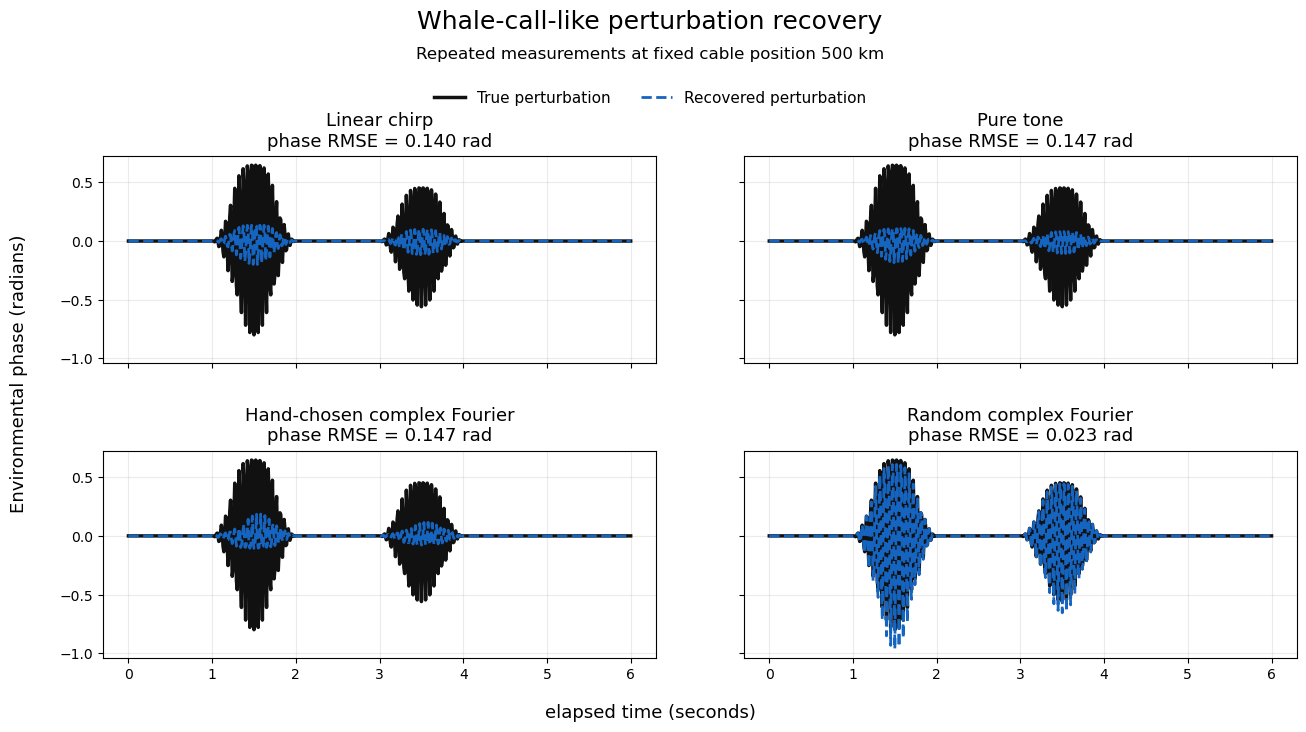

In [7]:
# Compare the four interrogation signals for the whale-call-like field.
make_recovery_slide("Whale-call-like")


### Seismic recovery: four interrogation signals


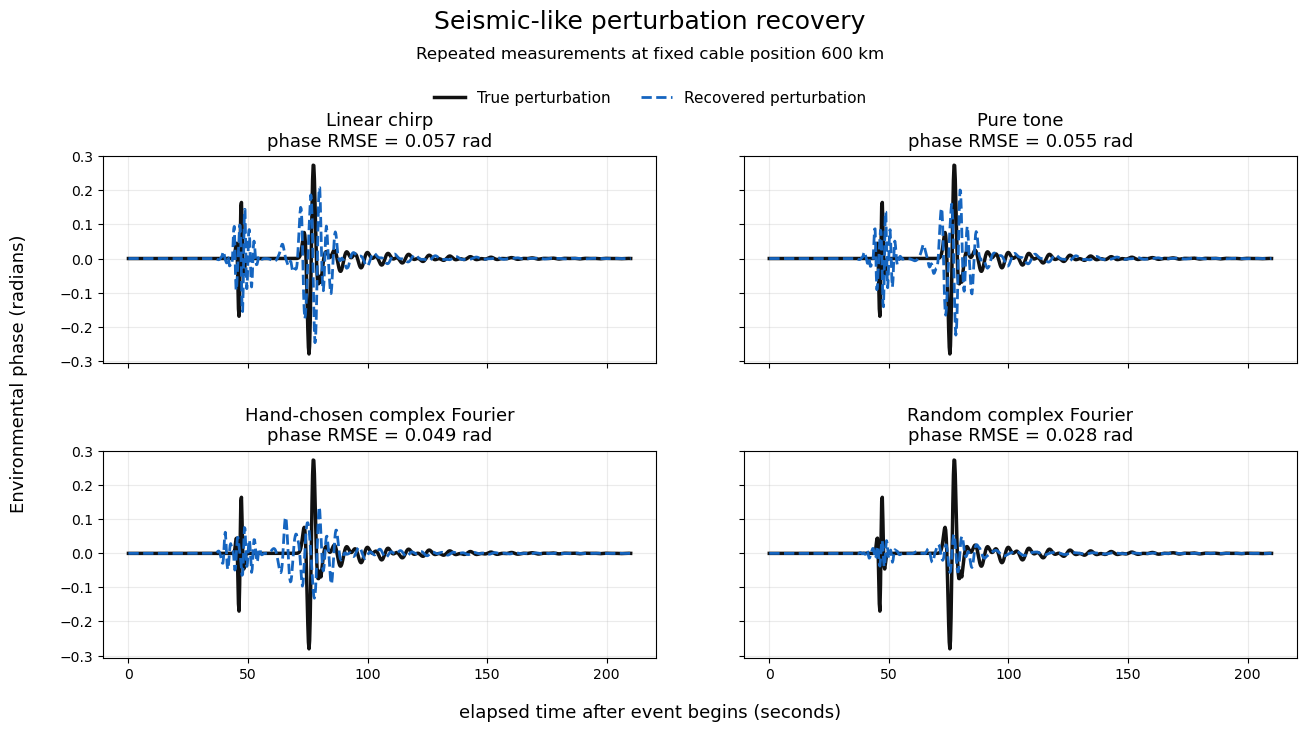

In [8]:
# Compare the four interrogation signals for the seismic-like field.
make_recovery_slide("Seismic-like")


### Temperature recovery: four interrogation signals


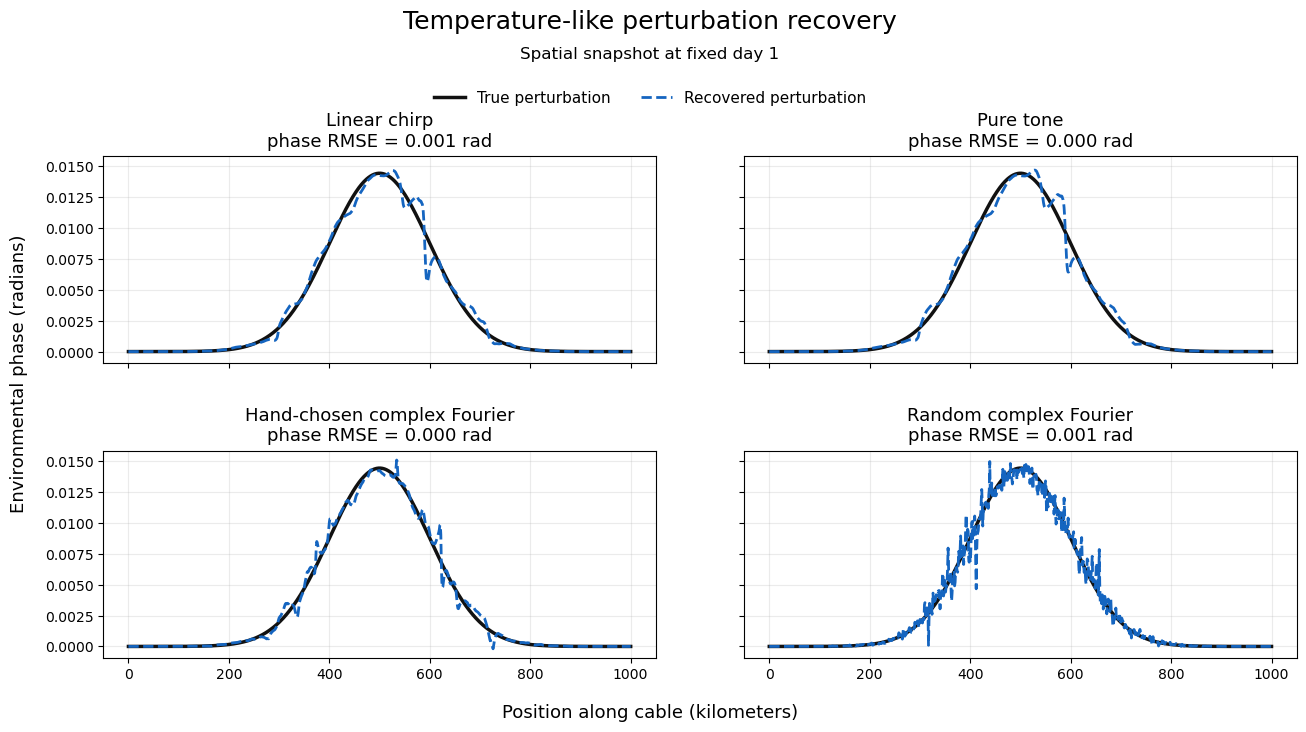

In [9]:
# Compare the four interrogation signals for the temperature-like field.
make_recovery_slide("Temperature-like")


## What is being plotted?

The colored curves are the final recovered environmental phase
\(\widehat g\), not the raw optical return.

For the first two rows, the plotted quantity is

$$
\widehat g(z_*,T),
$$

so position is fixed and environmental time changes. This represents many
separate, rapidly completed OFDR interrogations taken over several seconds.

For the temperature row, the plotted quantity is

$$
\widehat g(z,T_0),
\qquad T_0=1\text{ day},
$$

so observation day is fixed and position changes. It is one spatial snapshot
of the cable.

The first waveform figure uses interrogation pulse time in microseconds. These
microseconds describe the transmitted waveform itself; they are different from
the environmental seconds, days, or cable-position coordinates used in the
recovery figure.
